#Ejercicio 1

Iniciando la integración numérica de 3000 señales en la CPU. Esto tomará unos segundos...
Simulaciones completadas: 500 / 3000
Simulaciones completadas: 1000 / 3000
Simulaciones completadas: 1500 / 3000
Simulaciones completadas: 2000 / 3000
Simulaciones completadas: 2500 / 3000
Simulaciones completadas: 3000 / 3000
¡Generación de datos finalizada!

--- Evaluando ruido sigma = 0 ---


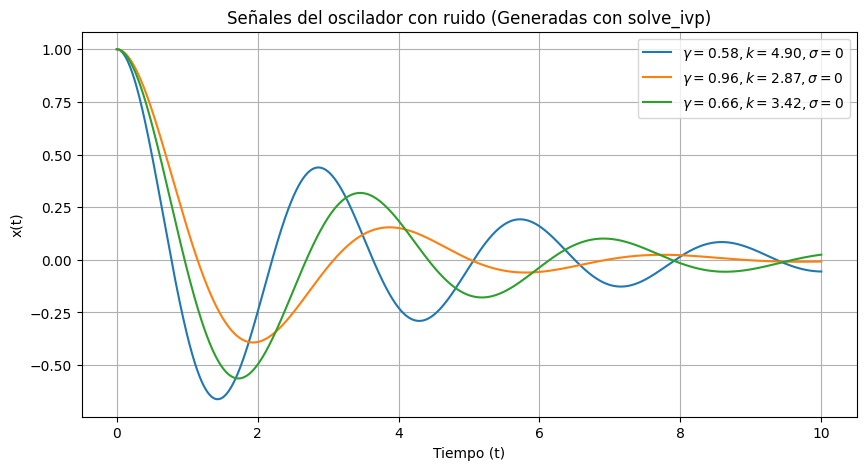

Entrenando red neuronal en: cuda
RF train -> RMSE Gamma: 0.0042, RMSE k: 0.0047
RF test  -> RMSE Gamma: 0.0099, RMSE k: 0.0099
---------------------------------------------------------------
MLP train -> RMSE Gamma: 0.0118, RMSE k: 0.0137
MLP test  -> RMSE Gamma: 0.0122, RMSE k: 0.0145

--- Evaluando ruido sigma = 0.01 ---


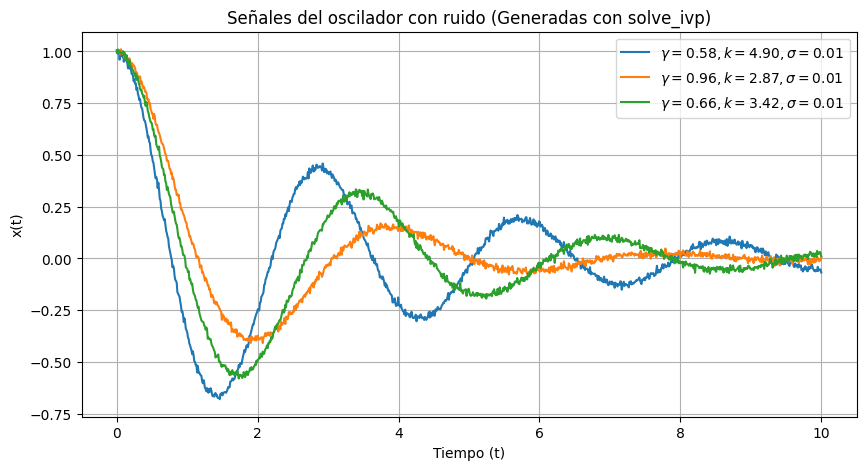

Entrenando red neuronal en: cuda
RF train -> RMSE Gamma: 0.0054, RMSE k: 0.0364
RF test  -> RMSE Gamma: 0.0119, RMSE k: 0.0539
---------------------------------------------------------------
MLP train -> RMSE Gamma: 0.0119, RMSE k: 0.0334
MLP test  -> RMSE Gamma: 0.0126, RMSE k: 0.0357

--- Evaluando ruido sigma = 0.02 ---


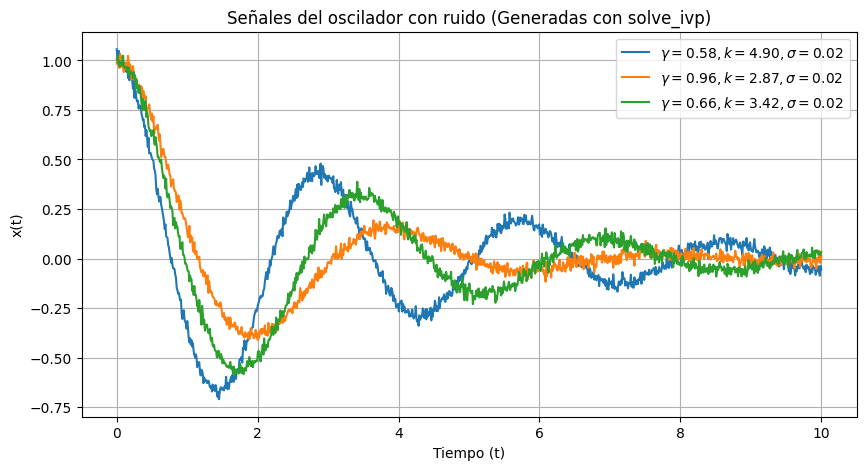

Entrenando red neuronal en: cuda
RF train -> RMSE Gamma: 0.0070, RMSE k: 0.0244
RF test  -> RMSE Gamma: 0.0154, RMSE k: 0.0453
---------------------------------------------------------------
MLP train -> RMSE Gamma: 0.0085, RMSE k: 0.0313
MLP test  -> RMSE Gamma: 0.0101, RMSE k: 0.0338

--- Evaluando ruido sigma = 0.05 ---


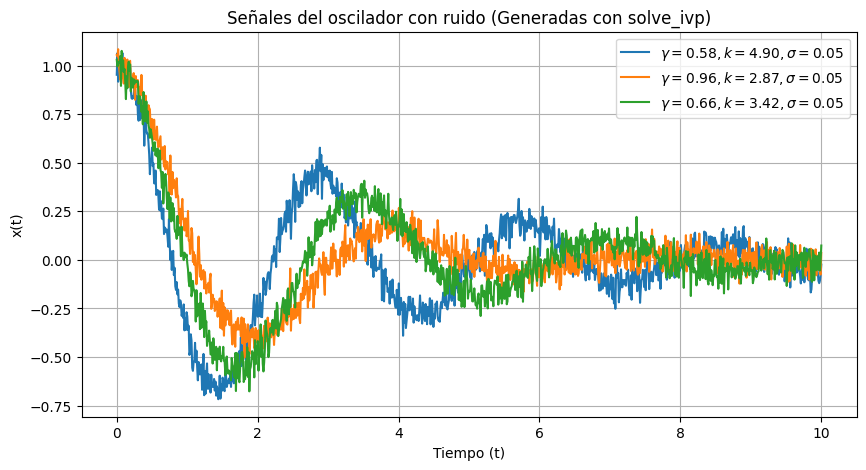

Entrenando red neuronal en: cuda
RF train -> RMSE Gamma: 0.0135, RMSE k: 0.0220
RF test  -> RMSE Gamma: 0.0301, RMSE k: 0.0593
---------------------------------------------------------------
MLP train -> RMSE Gamma: 0.0303, RMSE k: 0.0340
MLP test  -> RMSE Gamma: 0.0351, RMSE k: 0.0464

--- Evaluando ruido sigma = 0.1 ---


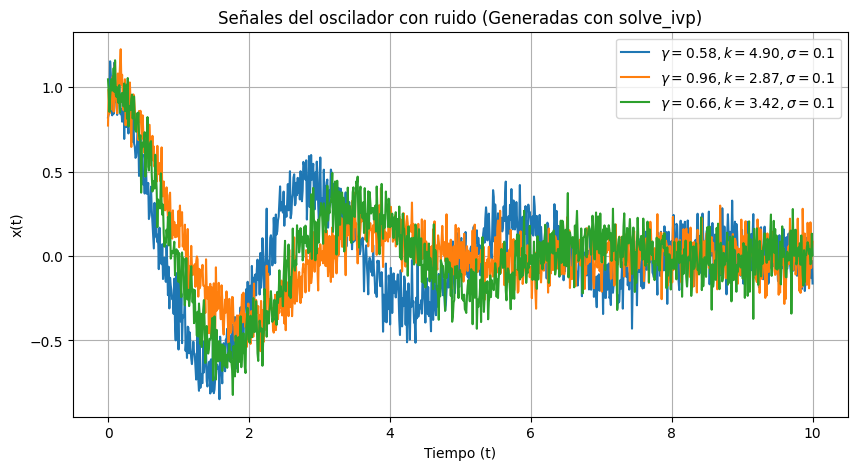

Entrenando red neuronal en: cuda
RF train -> RMSE Gamma: 0.0246, RMSE k: 0.0408
RF test  -> RMSE Gamma: 0.0569, RMSE k: 0.1137
---------------------------------------------------------------
MLP train -> RMSE Gamma: 0.0086, RMSE k: 0.0192
MLP test  -> RMSE Gamma: 0.0290, RMSE k: 0.0800


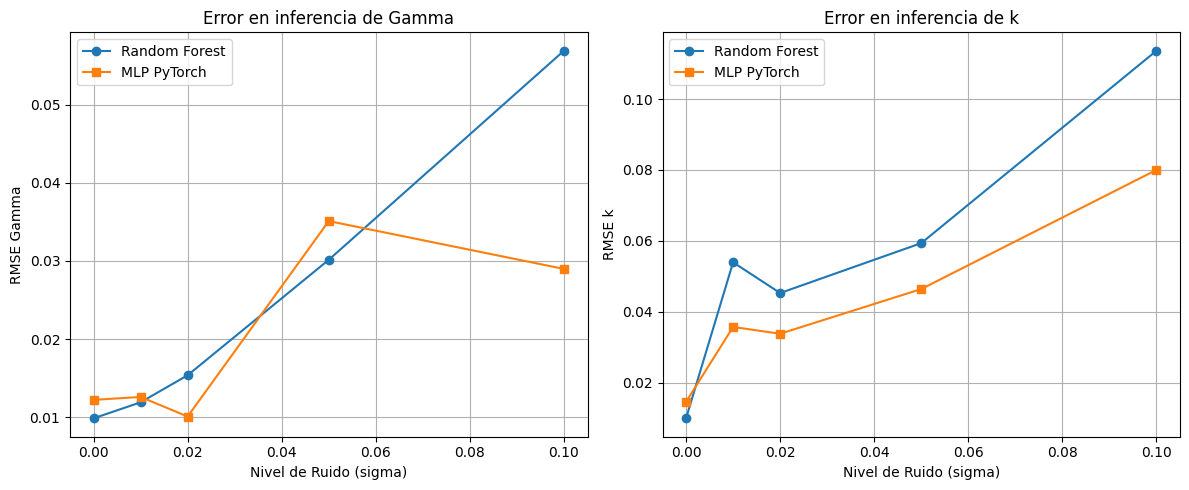

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from scipy.integrate import solve_ivp

# ==========================================
# Parte B: Generación de Datos con solve_ivp (CPU)
# ==========================================
N_samples = 3000
N_t = 1000
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], N_t)

# Muestreo de parámetros desde distribuciones uniformes
gamma_vals = np.random.uniform(0.05, 1.0, N_samples)
k_vals = np.random.uniform(1.0, 5.0, N_samples)
y_labels = np.column_stack((gamma_vals, k_vals)) # Etiquetas theta = (gamma, k)

def oscilador_edo(t, y, gamma, k):
    """
    Sistema de EDOs de primer orden.
    y[0] = x (posición)
    y[1] = v (velocidad)
    """
    return [y[1], -gamma * y[1] - k * y[0]]

# Matriz para almacenar las series temporales generadas
X_clean = np.zeros((N_samples, N_t))

print("Iniciando la integración numérica de 3000 señales en la CPU. Esto tomará unos segundos...")

for i in range(N_samples):
    # Condiciones iniciales: x(0)=1, v(0)=0
    y0 = [1.0, 0.0]

    # Resolver usando RK45 (Runge-Kutta de orden 4-5)
    sol = solve_ivp(
        fun=oscilador_edo,
        t_span=t_span,
        y0=y0,
        args=(gamma_vals[i], k_vals[i]),
        t_eval=t_eval,
        method='RK45'
    )

    # Extraemos únicamente la posición x(t)
    X_clean[i] = sol.y[0]

    # Rastreador de progreso
    if (i + 1) % 500 == 0:
        print(f"Simulaciones completadas: {i + 1} / {N_samples}")

print("¡Generación de datos finalizada!")

# ==========================================
# Definición del Modelo PyTorch (Parte C)
# ==========================================
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(SimpleMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 2) # Salida: gamma y k
        )

    def forward(self, x):
        return self.network(x)
def train_pytorch_model(X_train, y_train, X_test, y_test, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Entrenando red neuronal en: {device}")

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    X_te = torch.tensor(X_test, dtype=torch.float32)

    dataset = TensorDataset(X_tr, y_tr)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model = SimpleMLP(input_size=X_train.shape[1], hidden_size=128).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss_list = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            epoch_loss += loss.item()
            loss.backward()
            optimizer.step()

        train_loss_list.append(epoch_loss / len(dataloader))

    # Fase de Evaluación
    model.eval()
    with torch.no_grad():
        X_te_gpu = X_te.to(device)
        preds_te = model(X_te_gpu).cpu().numpy()
        X_tr_gpu = X_tr.to(device)
        preds_tr = model(X_tr_gpu).cpu().numpy()

    # Calcular RMSE para Testeo
    rmse_gamma_test = np.sqrt(np.mean((y_test[:, 0] - preds_te[:, 0])**2))
    rmse_k_test = np.sqrt(np.mean((y_test[:, 1] - preds_te[:, 1])**2))

    # Calcular RMSE para Entrenamiento
    rmse_gamma_train = np.sqrt(np.mean((y_train[:, 0] - preds_tr[:, 0])**2))
    rmse_k_train = np.sqrt(np.mean((y_train[:, 1] - preds_tr[:, 1])**2))

    return rmse_gamma_train, rmse_k_train, rmse_gamma_test, rmse_k_test

# ============================================
# Parte D: Estudio del efecto del ruido
# ==========================================
noise_levels = [0, 0.01, 0.02, 0.05, 0.10]
results_rf = {'gamma': [], 'k': []}
results_mlp = {'gamma': [], 'k': []}

for sigma in noise_levels:
    print(f"\n--- Evaluando ruido sigma = {sigma} ---")
    #ruido gaussiano
    noise = np.random.normal(0, sigma, X_clean.shape)
    X_noisy = X_clean + noise

    #graficado de señales generadas + ruido:
    plt.figure(figsize=(10, 5))
    for i in range(3):
        plt.plot(t_eval, X_noisy[i], label=f"$\gamma={gamma_vals[i]:.2f}, k={k_vals[i]:.2f}, \sigma={sigma}$")
    plt.title("Señales del oscilador con ruido (Generadas con solve_ivp)")
    plt.xlabel("Tiempo (t)")
    plt.ylabel("x(t)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # split 80/20
    X_train, X_test, y_train, y_test = train_test_split(X_noisy, y_labels, test_size=0.20, random_state=42)


    rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    preds_rf_train = rf.predict(X_train)
    preds_rf_test = rf.predict(X_test)

    # Calcular RMSE para Entrenamiento (para ver overfitting)
    rmse_gamma_rf_train = root_mean_squared_error(y_train[:, 0], preds_rf_train[:, 0])
    rmse_k_rf_train = root_mean_squared_error(y_train[:, 1], preds_rf_train[:, 1])

    # Calcular RMSE para Testeo
    rmse_gamma_rf_test = root_mean_squared_error(y_test[:, 0], preds_rf_test[:, 0])
    rmse_k_rf_test = root_mean_squared_error(y_test[:, 1], preds_rf_test[:, 1])



    results_rf['gamma'].append(rmse_gamma_rf_test)
    results_rf['k'].append(rmse_k_rf_test)

    # 2. PyTorch MLP (GPU)

    rmse_gamma_train_mlp, rmse_k_train_mlp, rmse_gamma_test_mlp, rmse_k_test_mlp = train_pytorch_model(X_train, y_train, X_test, y_test, epochs=100)


    results_mlp['gamma'].append(rmse_gamma_test_mlp)
    results_mlp['k'].append(rmse_k_test_mlp)

    print(f"RF train -> RMSE Gamma: {rmse_gamma_rf_train:.4f}, RMSE k: {rmse_k_rf_train:.4f}")
    print(f"RF test  -> RMSE Gamma: {rmse_gamma_rf_test:.4f}, RMSE k: {rmse_k_rf_test:.4f}")
    print("---------------------------------------------------------------")
    print(f"MLP train -> RMSE Gamma: {rmse_gamma_train_mlp:.4f}, RMSE k: {rmse_k_train_mlp:.4f}")
    print(f"MLP test  -> RMSE Gamma: {rmse_gamma_test_mlp:.4f}, RMSE k: {rmse_k_test_mlp:.4f}")



# Graficar resultados del estudio de ruido
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(noise_levels, results_rf['gamma'], 'o-', label='Random Forest')
plt.plot(noise_levels, results_mlp['gamma'], 's-', label='MLP PyTorch')
plt.xlabel('Nivel de Ruido (sigma)')
plt.ylabel('RMSE Gamma')
plt.title('Error en inferencia de Gamma')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(noise_levels, results_rf['k'], 'o-', label='Random Forest')
plt.plot(noise_levels, results_mlp['k'], 's-', label='MLP PyTorch')
plt.xlabel('Nivel de Ruido (sigma)')
plt.ylabel('RMSE k')
plt.title('Error en inferencia de k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("tarea2P1.png", dpi=300)
plt.show()